# 🏗️ Graph Construction — Elliptic Bitcoin Dataset

**Goal:** Transform the raw CSV files into a PyTorch Geometric (PyG) `Data` object ready for GNN training.

**Pipeline:**
```
Raw CSVs → Node Features (Tensor) → Edge Index → Labels → Masks → Normalization → Saved .pt file
```

---

### Notebook Structure

| # | Section | Purpose |
|---|---------|---------|
| 1 | Imports & Config | Load libraries, set paths |
| 2 | Load Raw Data | Read 3 CSVs, build node mapping |
| 3 | Build PyG Data Object | Features tensor + edge index + labels |
| 4 | Feature Normalization | Z-score normalize (training nodes only) |
| 5 | Train/Val/Test Masks | 70/15/15 split on labeled nodes |
| 6 | Class Weights | Inverse-frequency weights for loss function |
| 7 | Graph Statistics | Summary of the constructed graph |
| 8 | Degree Distribution | In/out degree histograms by class |
| 9 | Graph Connectivity | Connected components, self-loops, isolated nodes |
| 10 | Save Processed Graph | Save to `data/processed/elliptic_graph.pt` |
| 11 | Key Takeaways | Summary of findings |

---
## 1. Imports & Config

**What:** Load all necessary libraries and configure paths.

**Libraries:**
- `pandas`, `numpy` — data handling
- `torch`, `torch_geometric` — graph construction
- `matplotlib`, `seaborn` — visualization
- `networkx` — graph analysis (connected components, etc.)

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

# Config
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.1)
PALETTE = {"Illicit": "#e74c3c", "Licit": "#2ecc71", "Unknown": "#95a5a6"}

RAW_DIR   = "../data/raw"
SAVE_DIR  = "../data/processed"
PLOT_DIR  = "../results/plots/graph"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print("✅ Imports loaded")

/Users/piyushmaji/Desktop/Project/GNN-FraudNet/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded


---
## 2. Load Raw Data

**What:** Read the three raw CSV files and construct a node mapping (txId → integer index).

**Files:**

| File | Columns | Rows |
|------|---------|------|
| `elliptic_txs_features.csv` | txId + 166 features | 203,769 |
| `elliptic_txs_edgelist.csv` | txId1, txId2 | 234,355 |
| `elliptic_txs_classes.csv` | txId, class | 203,769 |

**Label mapping:**
- `"1"` → `1` (illicit / fraud)
- `"2"` → `0` (licit / legit)
- `"unknown"` → `-1` (unlabeled)

In [2]:
# ── Features (no header: col 0 = txId, cols 1-166 = features)
features_df = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_features.csv"), header=None)
col_names = ["txId"] + [f"feat_{i}" for i in range(1, 167)]
features_df.columns = col_names

# ── Build node mapping: txId → integer index
node_mapping = {tx_id: i for i, tx_id in enumerate(features_df["txId"])}
print(f"Node mapping size: {len(node_mapping):,}")

# ── Edgelist
edges_df = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_edgelist.csv"))

# ── Classes
classes_df = pd.read_csv(os.path.join(RAW_DIR, "elliptic_txs_classes.csv"))
label_map = {"1": 1, "2": 0, "unknown": -1}
classes_df["label"] = classes_df["class"].astype(str).map(label_map)

print(f"Features shape : {features_df.shape}")
print(f"Edges shape    : {edges_df.shape}")
print(f"Classes shape  : {classes_df.shape}")

Node mapping size: 203,769
Features shape : (203769, 167)
Edges shape    : (234355, 2)
Classes shape  : (203769, 3)


---
## 3. Build PyG Data Object

**What:** Convert raw data into a PyTorch Geometric `Data` object.

**Steps:**
1. Extract the 166 numeric features → `data.x` (float tensor)
2. Map edge txIds to integer indices → `data.edge_index` (long tensor)
3. Build label array aligned to node order → `data.y` (long tensor)

**Note:** Feature column `feat_1` is the **timestep** (1–49). We keep it as a feature for now — models can learn temporal patterns.

In [3]:
# ── Node features: drop txId, keep 166 float columns
feature_cols = [c for c in features_df.columns if c.startswith("feat_")]
x = torch.tensor(features_df[feature_cols].values, dtype=torch.float)
print(f"x shape: {x.shape}")

# ── Edge index: map txIds to integer indices
edges_mapped = edges_df.copy()
edges_mapped["src"] = edges_mapped["txId1"].map(node_mapping)
edges_mapped["dst"] = edges_mapped["txId2"].map(node_mapping)

# Drop any edges with unmapped nodes
n_before = len(edges_mapped)
edges_mapped = edges_mapped.dropna(subset=["src", "dst"])
n_after = len(edges_mapped)
if n_before != n_after:
    print(f"⚠️  Dropped {n_before - n_after} edges with unmapped txIds")

src = torch.tensor(edges_mapped["src"].values, dtype=torch.long)
dst = torch.tensor(edges_mapped["dst"].values, dtype=torch.long)
edge_index = torch.stack([src, dst], dim=0)
print(f"edge_index shape: {edge_index.shape}")

# ── Labels: align to node_mapping order
num_nodes = len(node_mapping)
y = torch.full((num_nodes,), -1, dtype=torch.long)
for tx_id, cls in zip(classes_df["txId"], classes_df["label"]):
    idx = node_mapping.get(tx_id)
    if idx is not None:
        y[idx] = cls

print(f"y shape: {y.shape}")
print(f"Label counts — Illicit: {(y == 1).sum().item():,}, Licit: {(y == 0).sum().item():,}, Unknown: {(y == -1).sum().item():,}")

# ── Construct PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)
print(f"\n{data}")

x shape: torch.Size([203769, 166])
edge_index shape: torch.Size([2, 234355])
y shape: torch.Size([203769])
Label counts — Illicit: 4,545, Licit: 42,019, Unknown: 157,205

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769])


---
## 4. Feature Normalization

**What:** Z-score normalize features using **training node statistics only**.

**Why training stats only?**
- Using all-node stats would leak information from val/test sets into training
- This is a common but subtle data leakage mistake in graph learning

**Method:** For each feature column:
```
x_normalized = (x - mean_train) / std_train
```

**Note:** We create masks first (next section), then normalize. But for code clarity, we define the normalization function here and apply it after masking.

In [4]:
def normalize_features(data):
    """
    Z-score normalize features using training node statistics only.
    Must be called AFTER masks are created.
    """
    x = data.x.clone()
    train_mask = data.train_mask

    # Compute stats from training nodes only
    train_x = x[train_mask]
    mean = train_x.mean(dim=0)
    std = train_x.std(dim=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1.0

    # Normalize ALL nodes using training stats
    data.x = (x - mean) / std

    print(f"Normalized features using {train_mask.sum().item():,} training nodes")
    print(f"  Mean range: [{data.x[train_mask].mean(dim=0).min():.4f}, {data.x[train_mask].mean(dim=0).max():.4f}]")
    print(f"  Std  range: [{data.x[train_mask].std(dim=0).min():.4f}, {data.x[train_mask].std(dim=0).max():.4f}]")
    return data

print("✅ Normalization function defined (will be applied after masks)")

✅ Normalization function defined (will be applied after masks)


---
## 5. Train / Validation / Test Masks

**What:** Split the **labeled nodes only** (y ≠ -1) into train/val/test sets using boolean mask tensors.

**Split ratio:** 70% train / 15% validation / 15% test

**Why boolean masks (not index arrays)?**
- PyG convention: `data.train_mask` is a boolean tensor of shape `(num_nodes,)`
- During training, we mask the loss: `loss = F(logits[train_mask], y[train_mask])`
- Unknown nodes (y == -1) have `False` in all three masks but are still in the graph for message passing

**Important:** We use a fixed random seed for reproducibility.

In [5]:
def create_masks(data, train_ratio=0.7, val_ratio=0.15, seed=42):
    """
    Create boolean train/val/test masks on labeled nodes.
    Unknown nodes (y == -1) are masked out of all sets but remain in the graph.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    num_nodes = data.y.size(0)

    # Find labeled node indices
    labeled_mask = data.y != -1
    labeled_indices = labeled_mask.nonzero(as_tuple=True)[0].numpy()
    np.random.shuffle(labeled_indices)

    n_labeled = len(labeled_indices)
    n_train = int(n_labeled * train_ratio)
    n_val = int(n_labeled * val_ratio)

    train_idx = labeled_indices[:n_train]
    val_idx = labeled_indices[n_train:n_train + n_val]
    test_idx = labeled_indices[n_train + n_val:]

    # Create boolean masks
    data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True

    print(f"Labeled nodes: {n_labeled:,}")
    print(f"  Train : {data.train_mask.sum().item():,} ({data.train_mask.sum().item()/n_labeled*100:.1f}%)")
    print(f"  Val   : {data.val_mask.sum().item():,} ({data.val_mask.sum().item()/n_labeled*100:.1f}%)")
    print(f"  Test  : {data.test_mask.sum().item():,} ({data.test_mask.sum().item()/n_labeled*100:.1f}%)")

    # Class breakdown in each split
    for name, mask in [("Train", data.train_mask), ("Val", data.val_mask), ("Test", data.test_mask)]:
        illicit = (data.y[mask] == 1).sum().item()
        licit = (data.y[mask] == 0).sum().item()
        total = mask.sum().item()
        print(f"  {name:5s}: Illicit={illicit:,} ({illicit/total*100:.1f}%), Licit={licit:,} ({licit/total*100:.1f}%)")

    return data

data = create_masks(data)

Labeled nodes: 46,564
  Train : 32,594 (70.0%)
  Val   : 6,984 (15.0%)
  Test  : 6,986 (15.0%)
  Train: Illicit=3,197 (9.8%), Licit=29,397 (90.2%)
  Val  : Illicit=673 (9.6%), Licit=6,311 (90.4%)
  Test : Illicit=675 (9.7%), Licit=6,311 (90.3%)


---
### Apply Normalization

Now that masks exist, we can normalize features using training statistics only.

In [6]:
data = normalize_features(data)

Normalized features using 32,594 training nodes
  Mean range: [-0.0000, 0.0000]
  Std  range: [1.0000, 1.0000]


---
## 6. Class Weights

**What:** Compute inverse-frequency class weights for the weighted `CrossEntropyLoss`.

**Why?**
- The dataset is highly imbalanced (~9:1 licit to illicit)
- Without weighting, the model will learn to always predict "licit" and get ~90% accuracy
- We weight the loss so that misclassifying a rare illicit node costs more

**Formula:**
```
weight_c = N_train / (num_classes × count_c)
```

In [7]:
def get_class_weights(data):
    """Compute inverse-frequency weights for binary classification."""
    train_labels = data.y[data.train_mask]
    n_licit = (train_labels == 0).sum().item()
    n_illicit = (train_labels == 1).sum().item()
    n_total = n_licit + n_illicit

    w_licit = n_total / (2.0 * n_licit)
    w_illicit = n_total / (2.0 * n_illicit)

    weights = torch.tensor([w_licit, w_illicit], dtype=torch.float)

    print(f"Training set — Licit: {n_licit:,}, Illicit: {n_illicit:,}")
    print(f"Class weights: [Licit: {w_licit:.4f}, Illicit: {w_illicit:.4f}]")
    print(f"Effective ratio: 1 : {w_illicit/w_licit:.1f}")
    return weights

class_weights = get_class_weights(data)

Training set — Licit: 29,397, Illicit: 3,197
Class weights: [Licit: 0.5544, Illicit: 5.0976]
Effective ratio: 1 : 9.2


---
## 7. Graph Statistics Summary

**What:** Print a comprehensive summary of the constructed graph — node counts, edge counts, labeled/unknown breakdown, and basic degree statistics.

In [8]:
def inspect_graph(data):
    """Print comprehensive graph statistics."""
    num_nodes = data.x.size(0)
    num_edges = data.edge_index.size(1)
    num_features = data.x.size(1)

    labeled = (data.y != -1).sum().item()
    unknown = (data.y == -1).sum().item()
    illicit = (data.y == 1).sum().item()
    licit = (data.y == 0).sum().item()

    # Degree stats
    src_nodes = data.edge_index[0]
    dst_nodes = data.edge_index[1]

    out_deg = torch.zeros(num_nodes, dtype=torch.long)
    in_deg = torch.zeros(num_nodes, dtype=torch.long)
    for s in src_nodes:
        out_deg[s] += 1
    for d in dst_nodes:
        in_deg[d] += 1
    total_deg = in_deg + out_deg

    print("=" * 60)
    print("  GRAPH SUMMARY")
    print("=" * 60)
    print(f"  Nodes              : {num_nodes:,}")
    print(f"  Edges (directed)   : {num_edges:,}")
    print(f"  Features per node  : {num_features}")
    print(f"  Avg degree         : {total_deg.float().mean():.2f}")
    print(f"  Max degree         : {total_deg.max().item()}")
    print(f"  Isolated nodes     : {(total_deg == 0).sum().item():,}")
    print()
    print(f"  Labeled nodes      : {labeled:,} ({labeled/num_nodes*100:.1f}%)")
    print(f"    Illicit (fraud)  : {illicit:,}")
    print(f"    Licit (legit)    : {licit:,}")
    print(f"    Ratio (licit:ill): {licit/max(illicit,1):.1f} : 1")
    print(f"  Unknown nodes      : {unknown:,} ({unknown/num_nodes*100:.1f}%)")
    print()
    print(f"  Train mask         : {data.train_mask.sum().item():,}")
    print(f"  Val mask           : {data.val_mask.sum().item():,}")
    print(f"  Test mask          : {data.test_mask.sum().item():,}")
    print("=" * 60)

inspect_graph(data)

  GRAPH SUMMARY
  Nodes              : 203,769
  Edges (directed)   : 234,355
  Features per node  : 166
  Avg degree         : 2.30
  Max degree         : 473
  Isolated nodes     : 0

  Labeled nodes      : 46,564 (22.9%)
    Illicit (fraud)  : 4,545
    Licit (legit)    : 42,019
    Ratio (licit:ill): 9.2 : 1
  Unknown nodes      : 157,205 (77.1%)

  Train mask         : 32,594
  Val mask           : 6,984
  Test mask          : 6,986


---
## 8. Degree Distribution by Class

**What:** Visualize the in-degree and out-degree distributions, split by class (illicit vs licit).

**Why it matters:**
- If fraud nodes have distinctive degree patterns, this is a useful structural signal
- GNNs can naturally leverage this through message passing — nodes with many connections aggregate more information

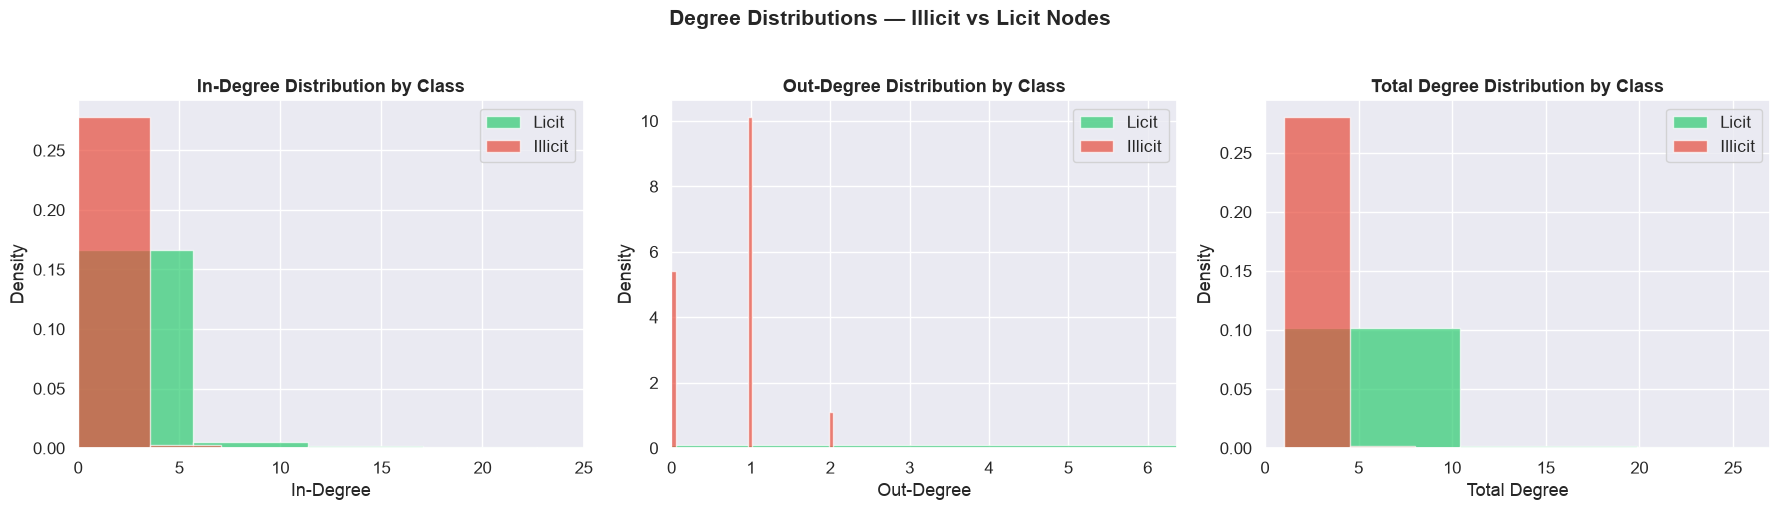


Degree statistics (labeled nodes only):
  In-degree    — Illicit: mean=1.27, median=1, max=177
               — Licit:   mean=1.91, median=1, max=284
  Out-degree   — Illicit: mean=0.74, median=1, max=3
               — Licit:   mean=1.19, median=1, max=472
  Total degree — Illicit: mean=2.01, median=1, max=177
               — Licit:   mean=3.10, median=2, max=473


In [9]:
# Compute degrees
src_nodes = data.edge_index[0].numpy()
dst_nodes = data.edge_index[1].numpy()
num_nodes = data.x.size(0)

out_deg = np.zeros(num_nodes, dtype=int)
in_deg = np.zeros(num_nodes, dtype=int)
for s in src_nodes:
    out_deg[s] += 1
for d in dst_nodes:
    in_deg[d] += 1
total_deg = in_deg + out_deg

labels = data.y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, deg_arr, title in zip(axes,
                               [in_deg, out_deg, total_deg],
                               ["In-Degree", "Out-Degree", "Total Degree"]):
    # Separate by class
    illicit_deg = deg_arr[labels == 1]
    licit_deg = deg_arr[labels == 0]

    ax.hist(licit_deg, bins=50, alpha=0.7, color=PALETTE["Licit"], label="Licit", density=True)
    ax.hist(illicit_deg, bins=50, alpha=0.7, color=PALETTE["Illicit"], label="Illicit", density=True)
    ax.set_title(f"{title} Distribution by Class", fontsize=13, fontweight="bold")
    ax.set_xlabel(title)
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_xlim(0, np.percentile(deg_arr[labels != -1], 99))

fig.suptitle("Degree Distributions — Illicit vs Licit Nodes", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/01_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"\nDegree statistics (labeled nodes only):")
for name, deg_arr in [("In-degree", in_deg), ("Out-degree", out_deg), ("Total degree", total_deg)]:
    ill = deg_arr[labels == 1]
    lic = deg_arr[labels == 0]
    print(f"  {name:12s} — Illicit: mean={ill.mean():.2f}, median={np.median(ill):.0f}, max={ill.max()}")
    print(f"  {' ':12s} — Licit:   mean={lic.mean():.2f}, median={np.median(lic):.0f}, max={lic.max()}")

---
## 9. Graph Connectivity Check

**What:** Analyze the graph's structural properties — connected components, self-loops, and isolated nodes.

**Why it matters:**
- If the graph is disconnected, some nodes can't receive messages from others → affects GNN performance
- Self-loops should typically be added for GNN message passing (so nodes include their own features)
- Isolated nodes get no neighborhood information — they degrade to a simple MLP

In [10]:
# Build a NetworkX graph for structural analysis
G = nx.DiGraph()
G.add_nodes_from(range(data.x.size(0)))
edges_np = data.edge_index.numpy()
edge_list = list(zip(edges_np[0], edges_np[1]))
G.add_edges_from(edge_list)

# Connected components (treat as undirected for connectivity)
G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
n_components = len(components)
largest_cc = max(components, key=len)
smallest_cc = min(components, key=len)

# Self-loops
self_loops = (data.edge_index[0] == data.edge_index[1]).sum().item()

# Isolated nodes
isolated = sum(1 for n in G.nodes() if G.degree(n) == 0)

print("=" * 60)
print("  GRAPH CONNECTIVITY")
print("=" * 60)
print(f"  Connected components   : {n_components:,}")
print(f"  Largest component      : {len(largest_cc):,} nodes ({len(largest_cc)/data.x.size(0)*100:.1f}%)")
print(f"  Smallest component     : {len(smallest_cc):,} nodes")
print(f"  Self-loops             : {self_loops:,}")
print(f"  Isolated nodes         : {isolated:,}")
print("=" * 60)

# Component size distribution (if many components)
if n_components > 1:
    sizes = sorted([len(c) for c in components], reverse=True)
    print(f"\nTop 10 component sizes: {sizes[:10]}")

  GRAPH CONNECTIVITY
  Connected components   : 49
  Largest component      : 7,880 nodes (3.9%)
  Smallest component     : 1,089 nodes
  Self-loops             : 0
  Isolated nodes         : 0

Top 10 component sizes: [7880, 7140, 6803, 6727, 6621, 6393, 6048, 5894, 5693, 5598]


---
## 10. Save Processed Graph

**What:** Save the fully processed PyG `Data` object to disk.

**Contents saved:**
- `data.x` — normalized node features (203,769 × 166)
- `data.edge_index` — edge connectivity (2 × 234,355)
- `data.y` — labels (203,769) with -1 for unknown
- `data.train_mask`, `data.val_mask`, `data.test_mask` — boolean split masks

In [11]:
save_path = os.path.join(SAVE_DIR, "elliptic_graph.pt")
torch.save(data, save_path)

# Verify the saved file
loaded = torch.load(save_path, weights_only=False)
print(f"✅ Saved to: {save_path}")
print(f"   File size: {os.path.getsize(save_path) / 1e6:.1f} MB")
print(f"\nVerification — loaded object:")
print(f"   {loaded}")
print(f"   x shape       : {loaded.x.shape}")
print(f"   edge_index    : {loaded.edge_index.shape}")
print(f"   y shape       : {loaded.y.shape}")
print(f"   train_mask sum: {loaded.train_mask.sum().item():,}")
print(f"   val_mask sum  : {loaded.val_mask.sum().item():,}")
print(f"   test_mask sum : {loaded.test_mask.sum().item():,}")

✅ Saved to: ../data/processed/elliptic_graph.pt
   File size: 141.3 MB

Verification — loaded object:
   Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
   x shape       : torch.Size([203769, 166])
   edge_index    : torch.Size([2, 234355])
   y shape       : torch.Size([203769])
   train_mask sum: 32,594
   val_mask sum  : 6,984
   test_mask sum : 6,986


---
## 11. Key Takeaways

### Graph Properties
- **203,769 nodes** with **234,355 directed edges** — a relatively sparse graph
- **166 features** per node (pre-normalized in the original dataset, now Z-score normalized using training stats)
- Only **~23%** of nodes are labeled → this is a **semi-supervised** learning problem

### Class Imbalance
- ~9:1 ratio of licit to illicit in labeled nodes
- Class weights computed for balanced loss: will upweight illicit class ~9×

### Masks
- 70/15/15 train/val/test split on labeled nodes only
- Unknown nodes remain in the graph for message passing but don't contribute to loss

### Connectivity
- The graph structure will allow GNNs to propagate information across neighborhoods
- Degree distributions show potential structural differences between illicit and licit nodes

### Next Steps
- **Notebook 03** → Train baseline models (Logistic Regression, XGBoost) that ignore graph structure
- **Notebook 04** → Train GNNs (GraphSAGE, GAT) that exploit graph structure
- The comparison will show whether graph-based models outperform feature-only baselines